# PI05 VLA Pipeline Walkthrough

This notebook is a step-by-step, sample-driven walkthrough of the `pi05` pipeline in the current `lerobot` codebase.

We follow two connected lines:

1. `Layer 1`: static sample line
   `dataset sample -> preprocess semantics -> policy input -> action`
2. `Layer 2`: dynamic environment line
   `env.reset -> raw observation -> env preprocess -> policy -> env.step -> next observation`

The goal is not training. The goal is to understand the actual VLA pipeline deeply enough that we can later modify the algorithm with confidence.

Important note:

- The official `pi05` preprocessing chain uses the gated tokenizer from `google/paligemma-3b-pt-224`.
- In this notebook we still reconstruct the official prompt text.
- But for stable execution, we inject mocked language tokens when calling the policy.

So this notebook explains the true dataflow, while keeping the tokenizer gate from blocking the rest of the analysis.

In [1]:
import importlib.util
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from IPython.display import display

from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.envs.configs import LiberoEnv as LiberoEnvConfig
from lerobot.envs.factory import make_env, make_env_pre_post_processors
from lerobot.envs.utils import add_envs_task, close_envs, preprocess_observation
from lerobot.policies.pi05 import PI05Policy
from lerobot.utils.constants import (
    ACTION,
    OBS_LANGUAGE_ATTENTION_MASK,
    OBS_LANGUAGE_TOKENS,
    OBS_STATE,
)

plt.rcParams["figure.figsize"] = (6, 6)
print("Imports loaded.")

/root/miniforge3/envs/lerobot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports loaded.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "lerobot/pi05_libero_base"
dataset_id = "lerobot/libero"
libero_suite = "libero_10"
libero_task_id = 0

print(f"device      : {device}")
print(f"model_id    : {model_id}")
print(f"dataset_id  : {dataset_id}")
print(f"libero_suite: {libero_suite}")
print(f"task_id     : {libero_task_id}")

device      : cuda
model_id    : lerobot/pi05_libero_base
dataset_id  : lerobot/libero
libero_suite: libero_10
task_id     : 0


In [3]:
def summarize_sample(sample: dict) -> None:
    print("Sample structure")
    for key, value in sample.items():
        if isinstance(value, torch.Tensor):
            print(f"  {key:<38} shape={list(value.shape)!s:<18} dtype={str(value.dtype):<15}")
        else:
            print(f"  {key:<38} type={type(value).__name__} value={value}")


def summarize_tensors(batch: dict, title: str) -> None:
    print(title)
    for key, value in batch.items():
        if isinstance(value, torch.Tensor):
            print(f"  {key:<38} shape={list(value.shape)!s:<18} dtype={str(value.dtype):<15}")
        elif isinstance(value, list):
            if value and isinstance(value[0], str):
                preview = value[0][:100]
                print(f"  {key:<38} list[str] first='{preview}'")
            else:
                print(f"  {key:<38} type=list")
        else:
            print(f"  {key:<38} type={type(value).__name__}")


def show_chw_image(img_tensor: torch.Tensor, title: str) -> None:
    img = img_tensor.detach().cpu().permute(1, 2, 0).numpy()
    plt.figure()
    plt.imshow(np.clip(img, 0.0, 1.0))
    plt.title(title)
    plt.axis("off")
    plt.show()


def flatten_keys(d: dict, prefix: str = "") -> list[str]:
    keys = []
    for key, value in d.items():
        name = f"{prefix}.{key}" if prefix else key
        if isinstance(value, dict):
            keys.extend(flatten_keys(value, name))
        else:
            keys.append(name)
    return keys


def normalize_quantiles(x: torch.Tensor, q01, q99) -> torch.Tensor:
    q01_t = torch.as_tensor(q01, dtype=torch.float32, device=x.device)
    q99_t = torch.as_tensor(q99, dtype=torch.float32, device=x.device)
    denom = q99_t - q01_t
    denom = torch.where(denom == 0, torch.tensor(1e-8, dtype=x.dtype, device=x.device), denom)
    return 2.0 * (x - q01_t) / denom - 1.0


def unnormalize_quantiles(x: torch.Tensor, q01, q99) -> torch.Tensor:
    q01_t = torch.as_tensor(q01, dtype=torch.float32, device=x.device)
    q99_t = torch.as_tensor(q99, dtype=torch.float32, device=x.device)
    denom = q99_t - q01_t
    denom = torch.where(denom == 0, torch.tensor(1e-8, dtype=x.dtype, device=x.device), denom)
    return (x + 1.0) * denom / 2.0 + q01_t


def build_prompt_from_state_and_task(state_1d: torch.Tensor, task: str, state_stats: dict) -> str:
    normalized_state = normalize_quantiles(state_1d.to(torch.float32), state_stats["q01"], state_stats["q99"])
    discretized = np.digitize(
        normalized_state.detach().cpu().numpy(),
        bins=np.linspace(-1, 1, 256 + 1)[:-1],
    ) - 1
    cleaned_task = task.strip().replace("_", " ").replace("\n", " ")
    state_str = " ".join(map(str, discretized.tolist()))
    return f"Task: {cleaned_task}, State: {state_str};\nAction: "


def add_mock_language_tokens(batch: dict[str, torch.Tensor], policy: PI05Policy, device: torch.device) -> None:
    max_len = policy.config.tokenizer_max_length
    batch[OBS_LANGUAGE_TOKENS] = torch.zeros((1, max_len), dtype=torch.long, device=device)
    batch[OBS_LANGUAGE_ATTENTION_MASK] = torch.zeros((1, max_len), dtype=torch.bool, device=device)


def build_static_model_batch(sample: dict, policy: PI05Policy, device: torch.device) -> dict[str, torch.Tensor]:
    batch = {}
    for key, value in sample.items():
        if isinstance(value, torch.Tensor):
            batch[key] = value.unsqueeze(0).to(device)
    add_mock_language_tokens(batch, policy, device)
    return batch


def ensure_libero_config() -> None:
    config_root = Path(os.environ.get("LIBERO_CONFIG_PATH", str(Path.home() / ".libero")))
    config_root.mkdir(parents=True, exist_ok=True)
    config_file = config_root / "config.yaml"
    if config_file.exists():
        return

    spec = importlib.util.find_spec("libero.libero")
    if spec is None or not spec.submodule_search_locations:
        raise ModuleNotFoundError("Could not locate installed `libero.libero` package.")

    benchmark_root = Path(spec.submodule_search_locations[0])
    config = {
        "benchmark_root": str(benchmark_root),
        "bddl_files": str(benchmark_root / "bddl_files"),
        "init_states": str(benchmark_root / "init_files"),
        "datasets": str((benchmark_root / "../datasets").resolve()),
        "assets": str(benchmark_root / "assets"),
    }
    with config_file.open("w") as f:
        yaml.safe_dump(config, f)


print("Helper functions defined.")

Helper functions defined.


## Layer 1: Static Sample Line

We start from a real LIBERO sample from the dataset cache.

1. What does one training / inference sample actually look like?
2. What are the image keys, state shape, action shape, and task text?
3. How does `pi05` turn `state + task` into a prompt?
4. What does the batch look like when it enters `PI05Policy.select_action()`?

In [4]:
policy = PI05Policy.from_pretrained(model_id).to(device)
policy.eval()

dataset = LeRobotDataset(dataset_id)
dataset_meta = dataset.meta
start_idx = dataset_meta.episodes["dataset_from_index"][0]
sample = dataset[start_idx]

print("Policy config summary")
print(f"  policy type          : {policy.name}")
print(f"  chunk_size           : {policy.config.chunk_size}")
print(f"  n_action_steps       : {policy.config.n_action_steps}")
print(f"  tokenizer_max_length : {policy.config.tokenizer_max_length}")
print(f"  expected image keys  : {list(policy.config.image_features.keys())}")
print()
summarize_sample(sample)

The PI05 model is a direct port of the OpenPI implementation. 
This implementation follows the original OpenPI structure for compatibility. 
Original implementation: https://github.com/Physical-Intelligence/openpi


Loading model from: lerobot/pi05_libero_base


✓ Loaded state dict from model.safetensors
Remapped 812 state dict keys
All keys loaded successfully!
Policy config summary
  policy type          : pi05
  chunk_size           : 50
  n_action_steps       : 10
  tokenizer_max_length : 200
  expected image keys  : ['observation.images.image', 'observation.images.image2', 'observation.images.empty_camera_0']

Sample structure
  observation.images.image               shape=[3, 256, 256]      dtype=torch.float32  
  observation.images.image2              shape=[3, 256, 256]      dtype=torch.float32  
  observation.state                      shape=[8]                dtype=torch.float32  
  action                                 shape=[7]                dtype=torch.float32  
  timestamp                              shape=[]                 dtype=torch.float32  
  frame_index                            shape=[]                 dtype=torch.int64    
  episode_index                          shape=[]                 dtype=torch.int64    
  index

Static sample visual and low-dimensional fields
task   : put the white mug on the left plate and put the yellow and white mug on the right plate
state  : [-5.3380046e-02  7.0296312e-03  6.7832810e-01  3.1407692e+00
  1.7593271e-03 -8.9944184e-02  3.8788661e-02 -3.8787212e-02]
action : [ 0.01607143  0.         -0.          0.          0.         -0.
 -1.        ]


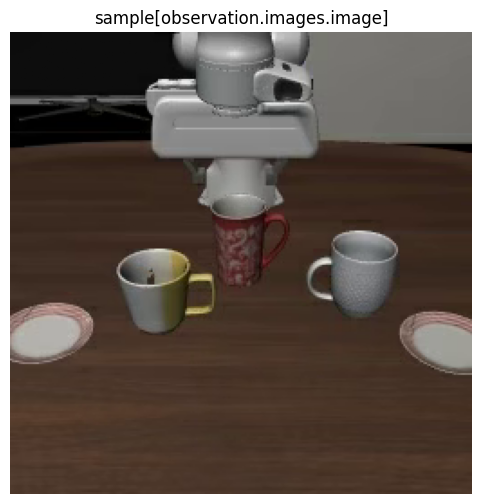

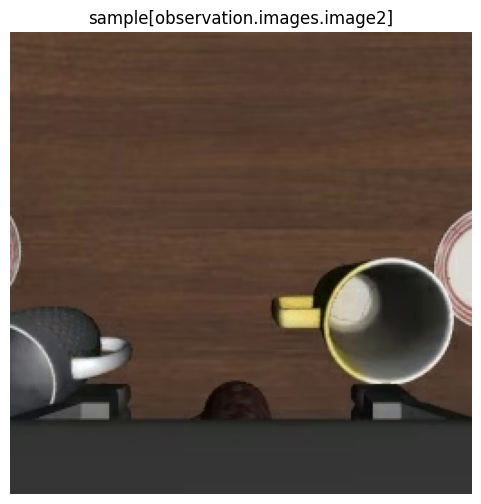

In [5]:
print("Static sample visual and low-dimensional fields")
print(f"task   : {sample['task']}")
print(f"state  : {sample['observation.state'].numpy()}")
print(f"action : {sample['action'].numpy()}")

show_chw_image(sample['observation.images.image'], 'sample[observation.images.image]')
show_chw_image(sample['observation.images.image2'], 'sample[observation.images.image2]')

In [6]:
state_stats = dataset_meta.stats[OBS_STATE]
raw_state = sample[OBS_STATE]
normalized_state = normalize_quantiles(raw_state, state_stats['q01'], state_stats['q99'])
prompt = build_prompt_from_state_and_task(raw_state, sample['task'], state_stats)

print('Raw state')
display(raw_state)
print('\nNormalized state in [-1, 1]')
display(normalized_state)
print('\nOfficial PI05-style prompt before tokenizer')
print('----------------------------------------')
print(prompt)
print('----------------------------------------')

Raw state


tensor([-5.3380e-02,  7.0296e-03,  6.7833e-01,  3.1408e+00,  1.7593e-03,
        -8.9944e-02,  3.8789e-02, -3.8787e-02])


Normalized state in [-1, 1]


tensor([ 0.1467, -0.2020, -0.6580,  0.7629,  0.3305,  0.0985,  0.9183, -0.9165])


Official PI05-style prompt before tokenizer
----------------------------------------
Task: put the white mug on the left plate and put the yellow and white mug on the right plate, State: 146 102 43 225 170 140 245 10;
Action: 
----------------------------------------


In [7]:
static_batch = build_static_model_batch(sample, policy, device)
summarize_tensors(static_batch, 'Batch sent into PI05Policy.select_action() for the static sample')

with torch.inference_mode():
    static_action = policy.select_action(static_batch)

print('\nStatic-line output action')
print(f'  shape : {list(static_action.shape)}')
print(f'  value : {static_action[0].detach().cpu().numpy()}')

print('\nInterpretation')
print('- We used a real sample for images/state/task.')
print('- We reconstructed the true prompt text.')
print('- We mocked language tokens so the gated tokenizer does not block the rest of the pipeline.')

Batch sent into PI05Policy.select_action() for the static sample
  observation.images.image               shape=[1, 3, 256, 256]   dtype=torch.float32  
  observation.images.image2              shape=[1, 3, 256, 256]   dtype=torch.float32  
  observation.state                      shape=[1, 8]             dtype=torch.float32  
  action                                 shape=[1, 7]             dtype=torch.float32  
  timestamp                              shape=[1]                dtype=torch.float32  
  frame_index                            shape=[1]                dtype=torch.int64    
  episode_index                          shape=[1]                dtype=torch.int64    
  index                                  shape=[1]                dtype=torch.int64    
  task_index                             shape=[1]                dtype=torch.int64    
  observation.language.tokens            shape=[1, 200]           dtype=torch.int64    
  observation.language.attention_mask    shape=[1, 200]

## Layer 2: Dynamic Environment Line

Now we switch from a cached dataset sample to a real online LIBERO environment.

Questions we answer in this section:

1. What does `env.reset()` actually return?
2. How does raw LIBERO observation become LeRobot observation?
3. Where does `task` enter the observation dict?
4. How does `robot_state` become the flattened 8-D `observation.state`?
5. Can we complete one online loop:
   `reset -> preprocess -> policy -> action -> env.step -> next observation`?

In [8]:
ensure_libero_config()

# If you rerun this cell, close the previous env first.
if 'envs' in globals():
    close_envs(envs)

env_cfg = LiberoEnvConfig(
    task=libero_suite,
    task_ids=[libero_task_id],
    control_mode='relative',
)

envs = make_env(env_cfg, n_envs=1, use_async_envs=False)
suite_name = next(iter(envs.keys()))
task_id = next(iter(envs[suite_name].keys()))
vec_env = envs[suite_name][task_id]
env_preprocessor, _ = make_env_pre_post_processors(env_cfg=env_cfg, policy_cfg=policy.config)

print(f'suite={suite_name}, task_id={task_id}')
raw_obs, reset_info = vec_env.reset(seed=0)
print('reset_info:', reset_info)
print('\nRaw observation keys from env.reset()')
for key in flatten_keys(raw_obs):
    print(' ', key)

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /root/miniforge3/envs/lerobot/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Creating LIBERO envs | suites=['libero_10'] | n_envs(per task)=1 | init_states=True
Restricting to task_ids=[0]
[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Local assets not found. Downloading from HuggingFace Hub...
Assets already downloaded at /root/.cache/libero/assets
Built vec env | suite=libero_10 | task_id=0 | n_envs=1
suite=libero_10, task_id=0
reset_info: {'is_success': array([False]), '_is_success': array([ True])}

Raw observation keys from env.reset()
  pixels.image
  pixels.image2
  robot_state.eef.mat
  robot_state.eef.pos
  robot_state.eef.quat
  robot_state.gripper.qpos
  robot_state.gripper.qvel
  robot_state.joints.pos
  robot_state.joints.vel


After preprocess_observation(raw_obs)
  observation.images.image               shape=[1, 3, 256, 256]   dtype=torch.float32  
  observation.images.image2              shape=[1, 3, 256, 256]   dtype=torch.float32  
  observation.robot_state                type=dict
  task                                   list[str] first='put both the alphabet soup and the tomato sauce in the basket'

After add_envs_task(...)
  observation.images.image               shape=[1, 3, 256, 256]   dtype=torch.float32  
  observation.images.image2              shape=[1, 3, 256, 256]   dtype=torch.float32  
  observation.robot_state                type=dict
  task                                   list[str] first='put both the alphabet soup and the tomato sauce in the basket'

After LiberoProcessorStep
  action                                 type=NoneType
  next.reward                            type=float
  next.done                              type=bool
  next.truncated                         type=bool
  in

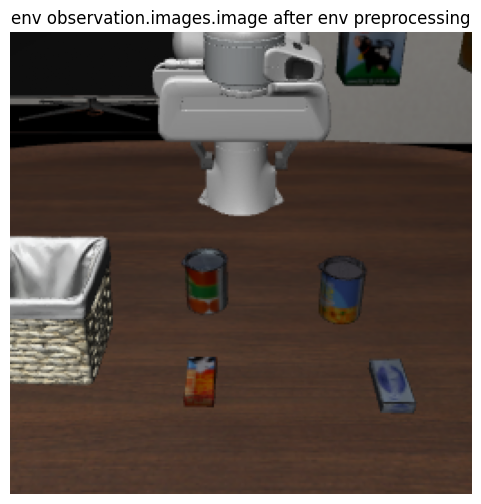

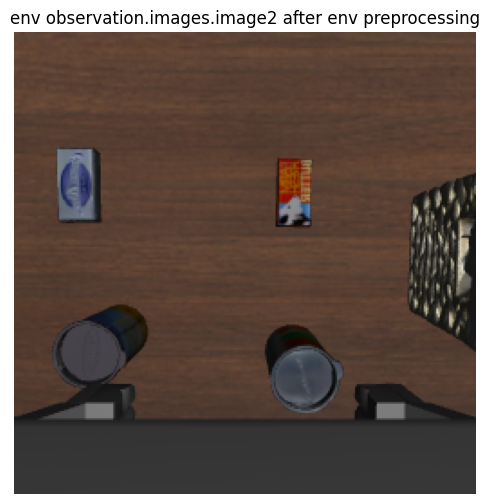

In [9]:
obs_after_preprocess = preprocess_observation(raw_obs)
obs_after_task = add_envs_task(vec_env, obs_after_preprocess)
obs_after_libero = env_preprocessor(obs_after_task)

summarize_tensors(obs_after_preprocess, 'After preprocess_observation(raw_obs)')
print()
summarize_tensors(obs_after_task, 'After add_envs_task(...)')
print()
summarize_tensors(obs_after_libero, 'After LiberoProcessorStep')

show_chw_image(obs_after_libero['observation.images.image'][0], 'env observation.images.image after env preprocessing')
show_chw_image(obs_after_libero['observation.images.image2'][0], 'env observation.images.image2 after env preprocessing')

In [10]:
env_prompt = build_prompt_from_state_and_task(
    obs_after_libero[OBS_STATE][0],
    obs_after_libero['task'][0],
    dataset_meta.stats[OBS_STATE],
)

print('Prompt reconstructed from the online LIBERO observation')
print('----------------------------------------')
print(env_prompt)
print('----------------------------------------')

online_batch = {}
for key, value in obs_after_libero.items():
    if isinstance(value, torch.Tensor):
        online_batch[key] = value.to(device)
add_mock_language_tokens(online_batch, policy, device)

summarize_tensors(online_batch, 'Batch sent into PI05Policy.select_action() for the online env observation')

with torch.inference_mode():
    online_action_norm = policy.select_action(online_batch)

action_stats = dataset_meta.stats[ACTION]
online_action_env = unnormalize_quantiles(online_action_norm, action_stats['q01'], action_stats['q99'])

print('\nNormalized action from policy')
print(online_action_norm[0].detach().cpu().numpy())
print('\nEnv-scale action after unnormalization')
print(online_action_env[0].detach().cpu().numpy())

Prompt reconstructed from the online LIBERO observation
----------------------------------------
Task: put both the alphabet soup and the tomato sauce in the basket, State: 154 94 68 225 169 142 244 11;
Action: 
----------------------------------------
Batch sent into PI05Policy.select_action() for the online env observation
  observation.images.image               shape=[1, 3, 256, 256]   dtype=torch.float32  
  observation.images.image2              shape=[1, 3, 256, 256]   dtype=torch.float32  
  observation.state                      shape=[1, 8]             dtype=torch.float32  
  observation.language.tokens            shape=[1, 200]           dtype=torch.int64    
  observation.language.attention_mask    shape=[1, 200]           dtype=torch.bool     

Normalized action from policy
[-0.1291746  -0.17075667 -0.09536079 -0.09874101 -0.03222658 -0.22577125
 -0.98286957]

Env-scale action after unnormalization
[ 0.00674289 -0.04997659 -0.06376547 -0.00287267  0.00739423 -0.0351047
 -0

Step output
  reward     : [0.]
  terminated : [False]
  truncated  : [False]
  step_info keys: ['task', '_task', 'task_id', '_task_id', 'done', '_done', 'is_success', '_is_success']

Next observation after one env.step(action) and preprocessing
  action                                 type=NoneType
  next.reward                            type=float
  next.done                              type=bool
  next.truncated                         type=bool
  info                                   type=dict
  task                                   list[str] first='put both the alphabet soup and the tomato sauce in the basket'
  observation.images.image               shape=[1, 3, 256, 256]   dtype=torch.float32  
  observation.images.image2              shape=[1, 3, 256, 256]   dtype=torch.float32  
  observation.state                      shape=[1, 8]             dtype=torch.float32  


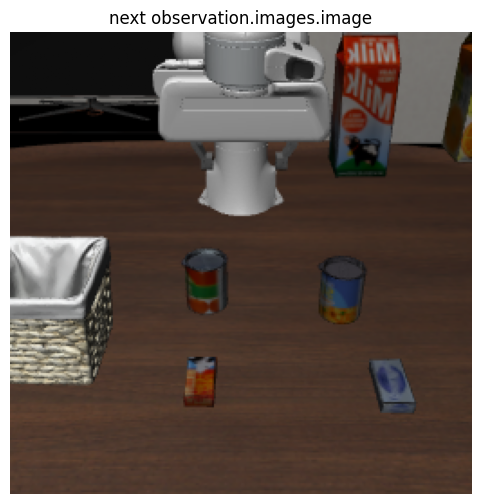

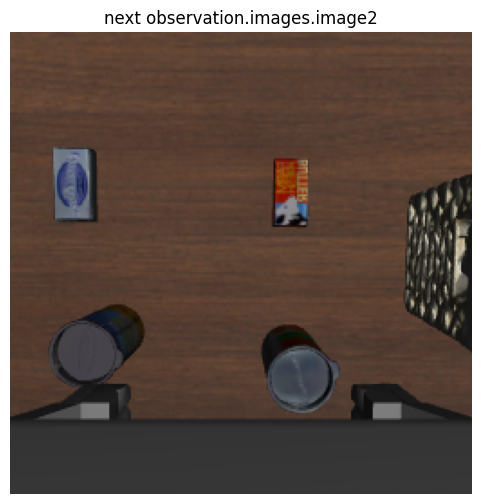

In [11]:
next_raw_obs, reward, terminated, truncated, step_info = vec_env.step(online_action_env.detach().cpu().numpy())

print('Step output')
print('  reward     :', reward)
print('  terminated :', terminated)
print('  truncated  :', truncated)
print('  step_info keys:', list(step_info.keys()))

next_obs = preprocess_observation(next_raw_obs)
next_obs = add_envs_task(vec_env, next_obs)
next_obs = env_preprocessor(next_obs)

print()
summarize_tensors(next_obs, 'Next observation after one env.step(action) and preprocessing')

show_chw_image(next_obs['observation.images.image'][0], 'next observation.images.image')
show_chw_image(next_obs['observation.images.image2'][0], 'next observation.images.image2')

## What This Notebook Proved

At this point we have validated the main `pi05` VLA loop in two complementary ways.

### Static line

- Real sample from `LeRobotDataset`
- Real image / state / task fields
- Reconstructed official `state -> prompt` logic
- `policy.select_action(...)` works on the sample

### Dynamic line

- Real `LIBERO` environment reset
- Raw env observation converted into LeRobot observation format
- `LiberoProcessorStep` turns nested `robot_state` into flat `observation.state`
- `policy.select_action(...)` produces an action
- Action is unnormalized and sent back to the environment with `env.step(...)`
- Environment returns a next observation

### The key architectural insight

`pi05` is not simply `image + continuous state vector -> action`.

Instead, the codebase is organized more like this:

1. visual observations stay visual
2. robot state is normalized and discretized
3. task text and discretized state are merged into a prompt
4. the model consumes `images + language tokens`
5. the model generates an action chunk, and `select_action()` returns one action from it

### What is still mocked in this notebook

The notebook reconstructs the correct prompt text, but does not run the official gated tokenizer path. Instead it injects mocked tokens so that the rest of the VLA pipeline stays fully inspectable and executable.

In [ ]:
# Optional cleanup cell
# Run this when you are done with the notebook session.

if 'envs' in globals():
    close_envs(envs)
    print('Closed LIBERO envs.')
else:
    print('No envs to close.')